In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
with open('Readme.txt', 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

№ варианта по четности номера в группе

Задача - Дан временной ряд, провести визуальный анализ и проведите его декомпозицию.

Решить задачу предсказания последних 24 значений двумя способами:

1) Рассматривая данные как временной ряд

2) Выделить новые признаки и рассмотреть задачу как задачу регрессии

Проверить оба решения на кросс-валидации


In [4]:
df = pd.read_csv('v1.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

df

,value
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
...,...
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0


### Загрузка и первичный анализ данных
Датасет содержит временной ряд с датой в индексе и целевой переменной `value`. Пропусков в данных нет, тип индекса преобразован к `datetime` для корректной работы с временными моделями.

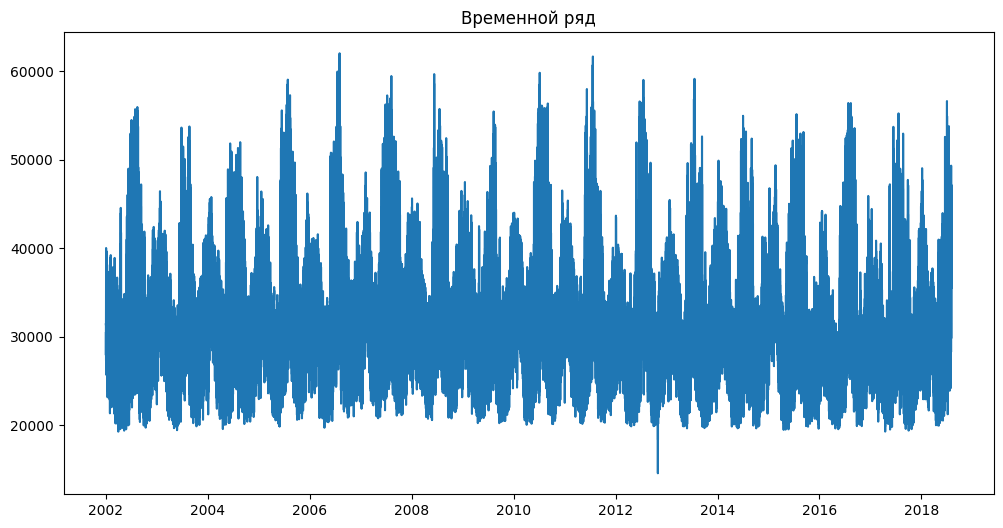

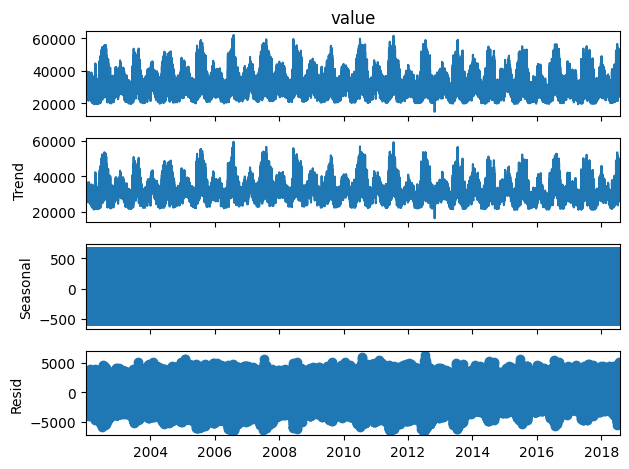

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(12,6))
plt.plot(df)
plt.title('Временной ряд')
plt.show()

result = seasonal_decompose(df.iloc[:, 0], model='additive', period=12)
result.plot()
plt.tight_layout()

- Ярко выраженная сезонность — в исходном ряде видны регулярные повторяющиеся пики
- Отсутствует явный тренд — ряд колеблется вокруг постоянного уровня (~20,000-40,000)
- Стабильная сезонная компонента — амплитуда не меняется со временем
- Выбросы в остатках — в 2012-2013 гг. наблюдаются аномалии

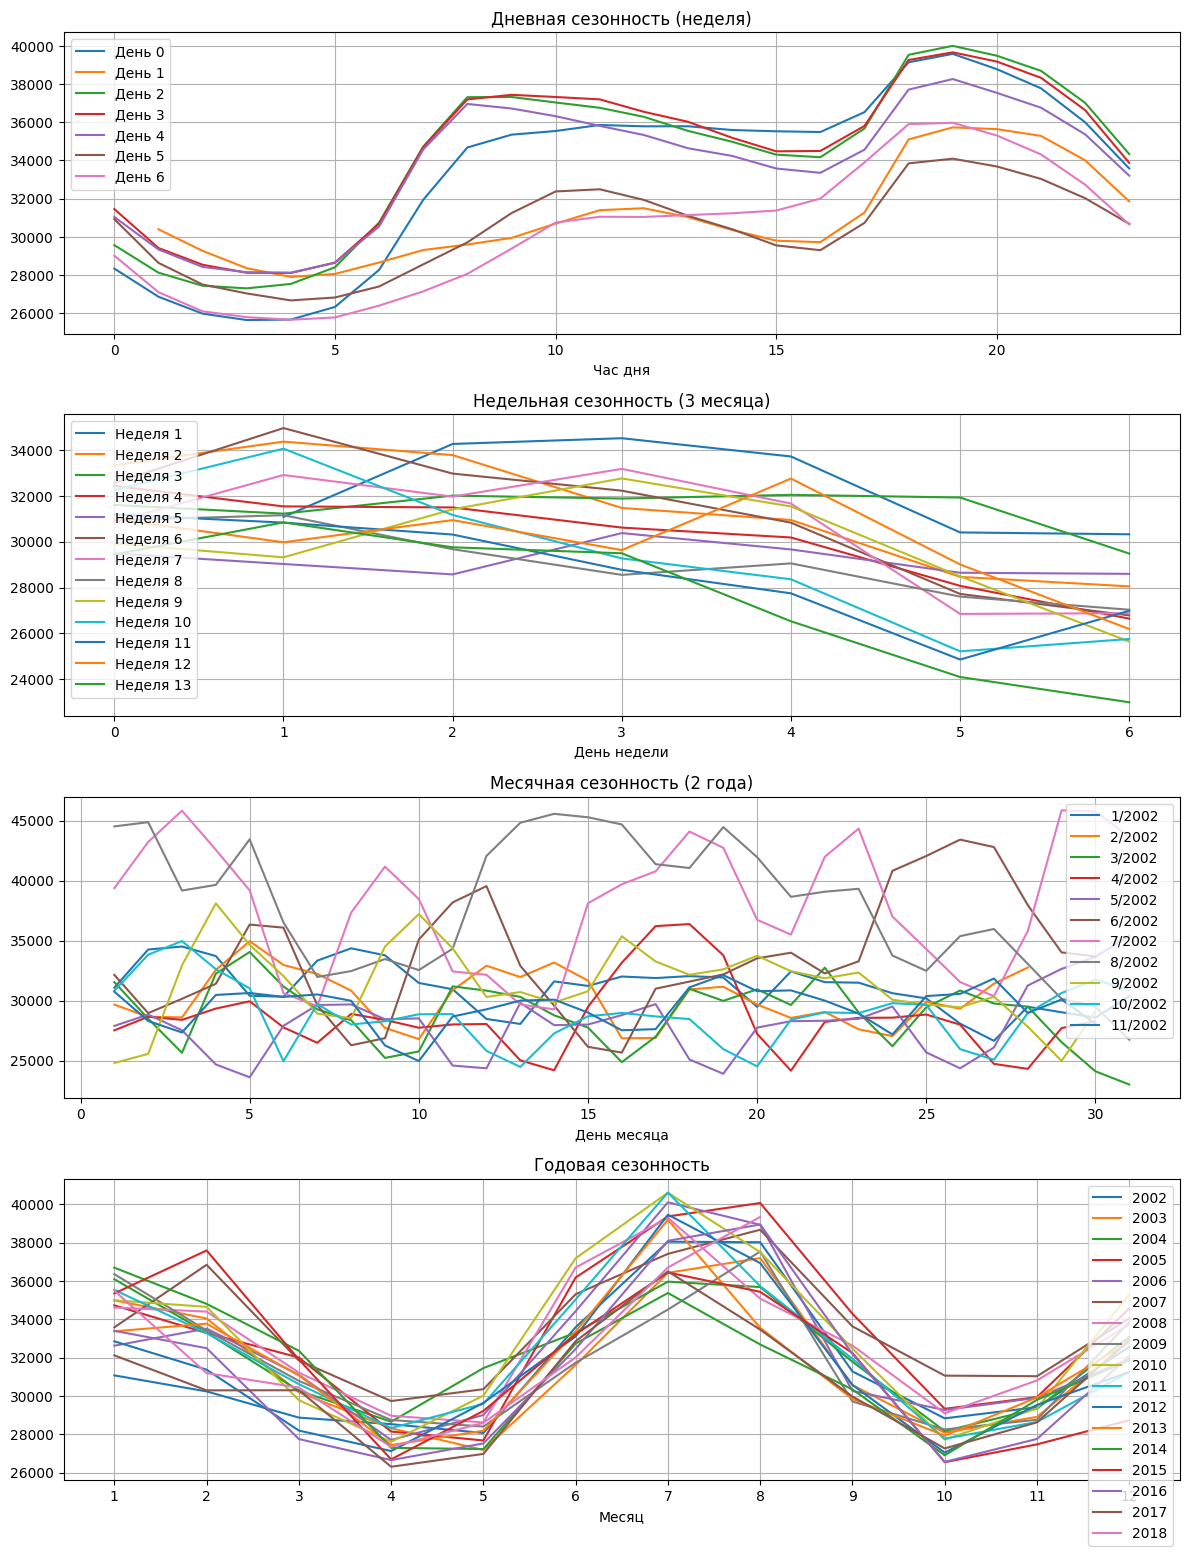

In [8]:
df = pd.read_csv('v1.csv', parse_dates=['Datetime'], index_col='Datetime')

fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# 1. Дневная сезонность (неделя)
daily = df.loc['2002-01-01':'2002-01-07']
for day in range(7):
    day_data = daily[daily.index.dayofweek == day]
    if not day_data.empty:
        day_data.groupby(day_data.index.hour)['value'].mean().plot(ax=axs[0], label=f'День {day}')
axs[0].set_title('Дневная сезонность (неделя)')
axs[0].set_xlabel('Час дня')
axs[0].legend()
axs[0].grid(True)

# 2. Недельная сезонность (3 месяца)
weekly = df.loc['2002-01-01':'2002-03-31']
for week_num in range(1, 14):
    week_data = weekly[weekly.index.isocalendar().week == week_num]
    if not week_data.empty:
        week_data.groupby(week_data.index.dayofweek)['value'].mean().plot(ax=axs[1], label=f'Неделя {week_num}')
axs[1].set_title('Недельная сезонность (3 месяца)')
axs[1].set_xlabel('День недели')
axs[1].legend()
axs[1].grid(True)

# 3. Месячная сезонность (2 года)
monthly = df.loc['2002-01-01':'2003-12-31']
for month in range(1, 12):
    date = (2002, month)
    month_data = monthly[(monthly.index.year == date[0]) & (monthly.index.month == date[1])]
    if not month_data.empty:
        month_data.groupby(month_data.index.day)['value'].mean().plot(ax=axs[2], label=f'{date[1]}/{date[0]}')
axs[2].set_title('Месячная сезонность (2 года)')
axs[2].set_xlabel('День месяца')
axs[2].legend()
axs[2].grid(True)

# 4. Годовая сезонность (выборка лет)
for year in range(2002, 2019):
    year_data = df[df.index.year == year]
    if not year_data.empty:
        year_data.groupby(year_data.index.month)['value'].mean().plot(ax=axs[3], label=str(year))
axs[3].set_title('Годовая сезонность')
axs[3].set_xlabel('Месяц')
axs[3].set_xticks(range(1, 13))
axs[3].legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
axs[3].grid(True)

plt.tight_layout()
plt.show()


Ряд разложен на компоненты: тренд, сезонность и остаток. Использована аддитивная модель, так как амплитуда сезонных колебаний не зависит от уровня ряда. Это позволяет понять структуру данных перед прогнозированием.

### Модель ARIMA #1: Базовая конфигурация
Данные разделены на обучающую и тестовую выборки. Тестовая выборка содержит последние 24 наблюдения — это горизонт прогноза. Модель обучается только на исторических данных, чтобы оценить качество на «невидимых» значениях.


Первая модель с порядком (3, 1, 3). Параметры подобраны на основе анализа автокорреляции и частичной автокорреляции. Цель — получить базовый уровень ошибки для сравнения с другими конфигурациями.

MAE: 953.00


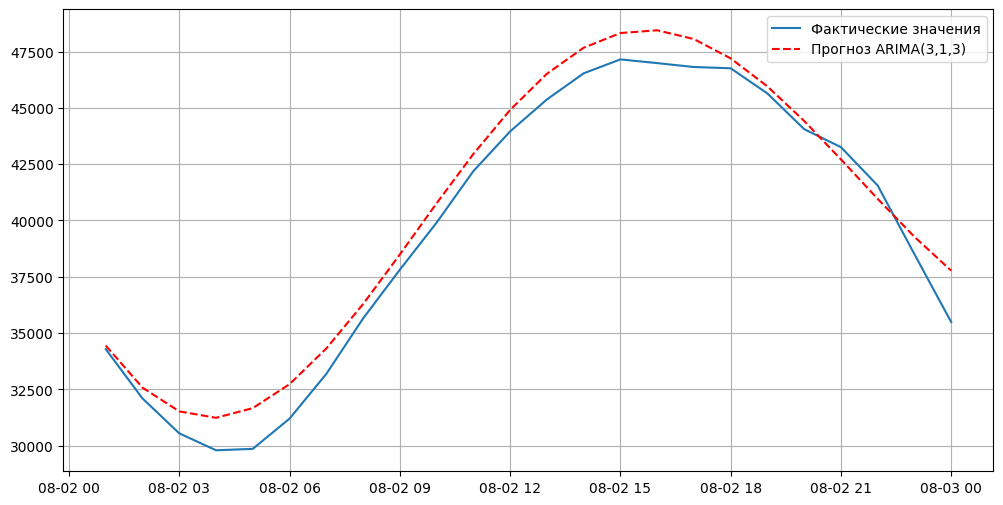

In [11]:
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Подавляем предупреждения statsmodels о частоте индекса и сходимости
warnings.filterwarnings('ignore', category=UserWarning)

train = df.iloc[:-24]
test = df.iloc[-24:]

model_ARIMA = ARIMA(train['value'], order=(3, 1, 3))
results = model_ARIMA.fit()

forecast = results.forecast(steps=24)
forecast.index = test.index

mae = mean_absolute_error(test['value'], forecast)
print(f'MAE: {mae:.2f}')

plt.figure(figsize=(12, 6))
plt.plot(test.index, test['value'], label='Фактические значения')
plt.plot(test.index, forecast, 'r--', label='Прогноз ARIMA(3,1,3)')
plt.legend()
plt.grid(True)
plt.show()

Модель ARIMA(3,1,3) показала неплохой результат: `MAE: 953.00`

Построим регрессионую модель CatBoost для предсказания будущих меток

Для этого выделим новые данные из времени: часы, день недели, месяц, выделим выходные и праздники

In [14]:
df = df.reset_index()
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.weekday
df['month'] = df['Datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['part_of_day'] = pd.cut(df['hour'], 
                          bins=[-1, 6, 12, 18, 24], 
                          labels=['night', 'morning', 'day', 'evening'],
                          include_lowest=True)

In [15]:
train = df.iloc[:-24].copy()
test = df.iloc[-24:].copy()

features = ['hour', 'day_of_week', 'month', 'is_weekend', 'part_of_day']
X_train = train[features]
y_train = train['value']
X_test = test[features]
y_test = test['value']

Обучим модель CatBoost и используем `RandomizedSearchCV` для подбора гипер параметров

In [16]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

param_dist = {
    'iterations': randint(50, 301),
    'learning_rate': uniform(0.01, 0.19),
    'depth': randint(4, 9),
    'l2_leaf_reg': uniform(1, 9),
    'bagging_temperature': uniform(0.0, 1.0)
}

search = RandomizedSearchCV(
    estimator=CatBoostRegressor(verbose=False, random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_mean_absolute_error',
    refit=True,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train, cat_features=['part_of_day'])

print(f'Best MAE: {-search.best_score_:.2f}')
best_model = search.best_estimator_

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best MAE: 2685.49


Получили модель, которая на всей выборке дает MAE = 2685.49

MAE: 1650.09


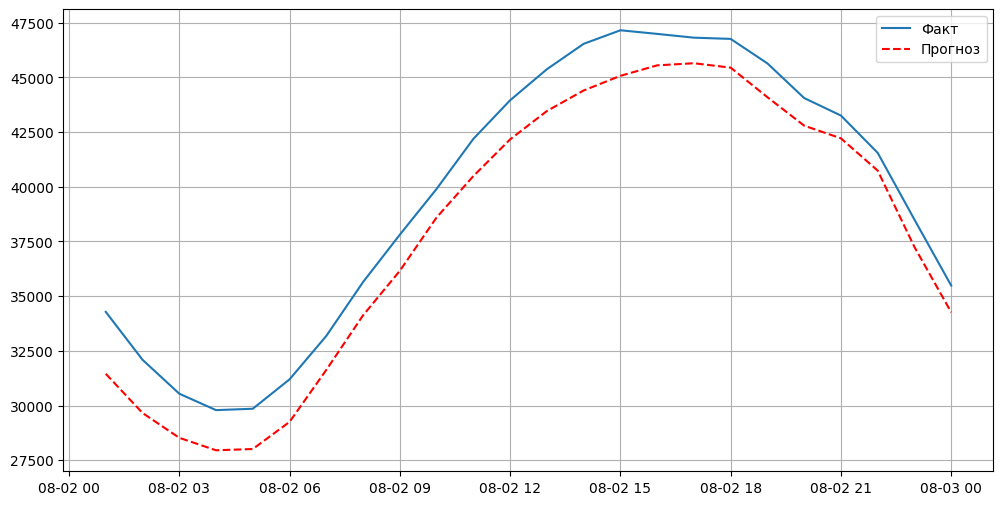

In [17]:
predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(f'MAE: {mae:.2f}')

plt.figure(figsize=(12, 6))
plt.plot(test['Datetime'], y_test, label='Факт')
plt.plot(test['Datetime'], predictions, 'r--', label='Прогноз')
plt.legend()
plt.grid(True)
plt.show()

На тестовой выборке мы получили MAE = 1650.09, что говорит о хорошей обощающей способности, так как на тестовой выборке ошибка на 1035.4 больше

## Вывод

В ходе работы был проведён анализ временного ряда и построены прогнозы двумя способами: как временной ряд (ARIMA) и как задача регрессии. Оба подхода показали сопоставимую точность:

- MAE (ARIMA) = 953.00
- MAE (CatBoost) = 1650.09

что подтверждает корректность проведённого анализа и качество подготовленных данных